In [10]:
!nvidia-smi

Wed Aug 19 19:15:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
from google.colab import drive
drive.mount('/content/drive')

!cp /content/drive/MyDrive/data.zip /content

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import os

print("Files in /content:")
for f in os.listdir("/content"):
    print(f)

Files in /content:
.config
bike.v1i.yolov8.zip
scooters.v1i.yolov8.zip
.ipynb_checkpoints
drive
car detection.v5-roboflow-instant-2--eval-.yolov8.zip
sample_data


In [7]:
import glob

zip_files = glob.glob("/content/*.zip")

print("ZIP files found:")
for f in zip_files:
    print(f)

ZIP files found:
/content/bike.v1i.yolov8.zip
/content/scooters.v1i.yolov8.zip
/content/car detection.v5-roboflow-instant-2--eval-.yolov8.zip


In [8]:
import zipfile
import os

zip_files = {
    "car": "/content/car detection.v5-roboflow-instant-2--eval-.yolov8.zip",
    "bike": "/content/bike.v1i.yolov8.zip",
    "scooty": "/content/scooters.v1i.yolov8.zip"
}

for name, zip_path in zip_files.items():

    output_path = f"/content/{name}_dataset"

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(output_path)

    print(f"✅ {name} dataset extracted")

✅ car dataset extracted
✅ bike dataset extracted
✅ scooty dataset extracted


In [9]:
import os

for dataset in ["car_dataset", "bike_dataset", "scooty_dataset"]:

    print("\n" + "="*50)
    print(dataset)
    print("="*50)

    base = "/content/" + dataset

    for root, dirs, files in os.walk(base):

        images = [
            f for f in files
            if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
        ]

        labels = [
            f for f in files
            if f.endswith(".txt")
        ]

        if images or labels:
            print(root)
            print("  Images:", len(images))
            print("  Labels:", len(labels))


car_dataset
/content/car_dataset
  Images: 0
  Labels: 2
/content/car_dataset/train/labels
  Images: 0
  Labels: 207
/content/car_dataset/train/images
  Images: 207
  Labels: 0
/content/car_dataset/valid/labels
  Images: 0
  Labels: 22
/content/car_dataset/valid/images
  Images: 22
  Labels: 0
/content/car_dataset/test/labels
  Images: 0
  Labels: 9
/content/car_dataset/test/images
  Images: 9
  Labels: 0

bike_dataset
/content/bike_dataset
  Images: 0
  Labels: 2
/content/bike_dataset/train/labels
  Images: 0
  Labels: 150
/content/bike_dataset/train/images
  Images: 150
  Labels: 0

scooty_dataset
/content/scooty_dataset
  Images: 0
  Labels: 2
/content/scooty_dataset/train/labels
  Images: 0
  Labels: 699
/content/scooty_dataset/train/images
  Images: 699
  Labels: 0
/content/scooty_dataset/valid/labels
  Images: 0
  Labels: 200
/content/scooty_dataset/valid/images
  Images: 200
  Labels: 0
/content/scooty_dataset/test/labels
  Images: 0
  Labels: 100
/content/scooty_dataset/test/i

In [11]:
from pathlib import Path
import os
import shutil
import random

# EXTRACTED dataset folders
datasets = {
    "car": "/content/car_dataset",
    "bike": "/content/bike_dataset",
    "scooty": "/content/scooty_dataset"
}

# Final class IDs
class_mapping = {
    "car": 0,
    "bike": 1,
    "scooty": 2
}

output = "/content/vehicle_dataset"

print("✅ Using extracted datasets:")
for name, path in datasets.items():
    print(name, "→", path)

✅ Using extracted datasets:
car → /content/car_dataset
bike → /content/bike_dataset
scooty → /content/scooty_dataset


In [12]:
all_images = []

for class_name, dataset_path in datasets.items():

    print("\nProcessing:", class_name)

    for split in ["train", "valid", "val", "test"]:

        image_dir = Path(dataset_path) / split / "images"
        label_dir = Path(dataset_path) / split / "labels"

        if not image_dir.exists():
            continue

        for image_path in image_dir.iterdir():

            if image_path.suffix.lower() not in [".jpg", ".jpeg", ".png", ".webp"]:
                continue

            label_path = label_dir / (image_path.stem + ".txt")

            if not label_path.exists():
                print("⚠️ Missing label:", image_path.name)
                continue

            all_images.append(
                (class_name, image_path, label_path)
            )

print("\n============================")
print("TOTAL DATA")
print("============================")

print("Total image-label pairs:", len(all_images))

for class_name in datasets:
    count = sum(
        1 for item in all_images
        if item[0] == class_name
    )
    print(class_name, ":", count)


Processing: car

Processing: bike

Processing: scooty

TOTAL DATA
Total image-label pairs: 1387
car : 238
bike : 150
scooty : 999


In [13]:
random.seed(42)

random.shuffle(all_images)

total = len(all_images)

train_end = int(0.80 * total)
val_end = int(0.90 * total)

train_data = all_images[:train_end]
val_data = all_images[train_end:val_end]
test_data = all_images[val_end:]

print("Train:", len(train_data))
print("Validation:", len(val_data))
print("Test:", len(test_data))

Train: 1109
Validation: 139
Test: 139


In [18]:
import os
import shutil
from pathlib import Path

output = "/content/vehicle_dataset"

# Create all required folders
for split in ["train", "val", "test"]:
    os.makedirs(f"{output}/images/{split}", exist_ok=True)
    os.makedirs(f"{output}/labels/{split}", exist_ok=True)

print("✅ All destination folders created")

# Check them
for split in ["train", "val", "test"]:
    print(
        split,
        "images:", os.path.exists(f"{output}/images/{split}"),
        "labels:", os.path.exists(f"{output}/labels/{split}")
    )

✅ All destination folders created
train images: True labels: True
val images: True labels: True
test images: True labels: True


In [19]:
def process_dataset(data, split):

    for class_name, image_path, label_path in data:

        new_class_id = class_mapping[class_name]

        new_name = f"{class_name}_{image_path.name}"

        destination_image = (
            Path(output) / "images" / split / new_name
        )

        shutil.copy2(str(image_path), str(destination_image))

        with open(label_path, "r") as f:
            lines = f.readlines()

        new_lines = []

        for line in lines:

            parts = line.strip().split()

            if len(parts) != 5:
                continue

            parts[0] = str(new_class_id)

            new_lines.append(" ".join(parts))

        destination_label = (
            Path(output) / "labels" / split /
            f"{Path(new_name).stem}.txt"
        )

        with open(destination_label, "w") as f:
            f.write("\n".join(new_lines))


process_dataset(train_data, "train")
process_dataset(val_data, "val")
process_dataset(test_data, "test")

print("✅ All images and labels combined!")

✅ All images and labels combined!


In [20]:
for split in ["train", "val", "test"]:

    image_dir = Path(output) / "images" / split
    label_dir = Path(output) / "labels" / split

    images = list(image_dir.iterdir())
    labels = list(label_dir.iterdir())

    print(
        split,
        "→ Images:",
        len(images),
        "Labels:",
        len(labels)
    )

train → Images: 1109 Labels: 1109
val → Images: 139 Labels: 139
test → Images: 139 Labels: 139


In [21]:
from collections import Counter

counter = Counter()

for split in ["train", "val", "test"]:

    label_dir = Path(output) / "labels" / split

    for label_file in label_dir.glob("*.txt"):

        with open(label_file, "r") as f:

            for line in f:

                if line.strip():

                    class_id = int(line.split()[0])
                    counter[class_id] += 1

print("Class IDs found:")

for class_id, count in sorted(counter.items()):

    class_name = {
        0: "car",
        1: "bike",
        2: "scooty"
    }.get(class_id, "UNKNOWN")

    print(
        class_id,
        "→",
        class_name,
        ":",
        count,
        "objects"
    )

Class IDs found:
0 → car : 574 objects
1 → bike : 200 objects
2 → scooty : 2144 objects


In [22]:
yaml_content = """
path: /content/vehicle_dataset

train: images/train
val: images/val
test: images/test

names:
  0: car
  1: bike
  2: scooty
"""

with open("/content/vehicle_dataset/data.yaml", "w") as f:
    f.write(yaml_content)

print(yaml_content)


path: /content/vehicle_dataset

train: images/train
val: images/val
test: images/test

names:
  0: car
  1: bike
  2: scooty



In [23]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 6.4 MB/s eta 0:00:00


In [24]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

results = model.train(
    data="/content/vehicle_dataset/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    device=0
)

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.123 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/vehicle_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=

In [41]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/train/weights/best.pt")

results = model.predict(
    source=[
        "/content/pic.jpg",
        "/content/pic 2.jpg",
        "/content/pic3.jpg"
    ],
    conf=0.5,
    save=True
)

print("Number of images processed:", len(results))


0: 640x640 3 scootys, 5.6ms
1: 640x640 8 scootys, 5.6ms
2: 640x640 1 car, 1 scooty, 5.6ms
Speed: 4.3ms preprocess, 5.6ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict-9
Number of images processed: 3


Result: pic 2.jpg


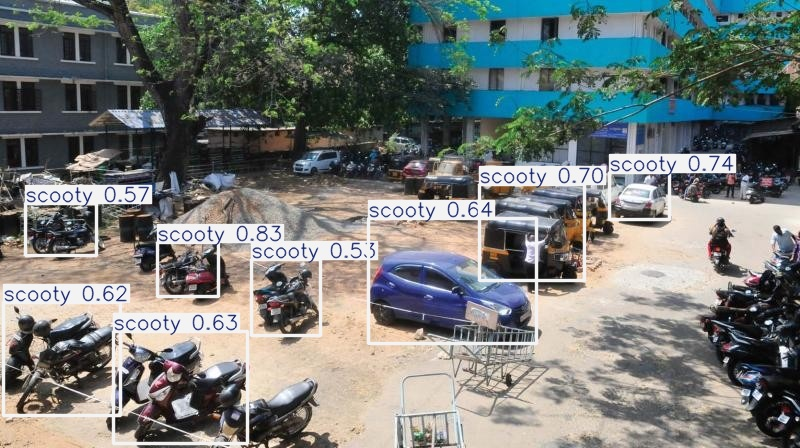

In [43]:
from IPython.display import Image, display
import glob
import os

result_files = glob.glob("/content/runs/detect/predict/*.jpg")

for file in result_files:
    print("Result:", os.path.basename(file))
    display(Image(filename=file))


0: 640x640 7 scootys, 5.6ms
1: 640x640 14 scootys, 5.6ms
2: 640x640 1 car, 1 scooty, 5.6ms
Speed: 3.0ms preprocess, 5.6ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict-10
Number of images processed: 3

========== IMAGE 1 ==========


array([[[ 55,  66,  74],
        [ 42,  53,  61],
        [ 62,  73,  81],
        ...,
        [ 48,  57,  60],
        [ 50,  59,  63],
        [ 50,  59,  63]],

       [[ 58,  69,  77],
        [ 49,  60,  68],
        [ 54,  65,  73],
        ...,
        [ 50,  59,  62],
        [ 51,  60,  64],
        [ 51,  60,  64]],

       [[ 59,  70,  78],
        [ 63,  74,  82],
        [ 51,  63,  69],
        ...,
        [ 49,  58,  61],
        [ 53,  62,  66],
        [ 53,  62,  66]],

       ...,

       [[110, 125, 127],
        [104, 119, 121],
        [ 81,  95, 101],
        ...,
        [ 30,  34,  35],
        [ 29,  34,  33],
        [ 29,  34,  33]],

       [[111, 126, 128],
        [106, 121, 123],
        [ 86, 100, 106],
        ...,
        [ 28,  32,  33],
        [ 26,  31,  30],
        [ 26,  31,  30]],

       [[110, 125, 127],
        [105, 120, 122],
        [ 87, 101, 107],
        ...,
        [ 26,  30,  31],
        [ 24,  29,  28],
        [ 24,  29,  28]]], dtype=uint8)
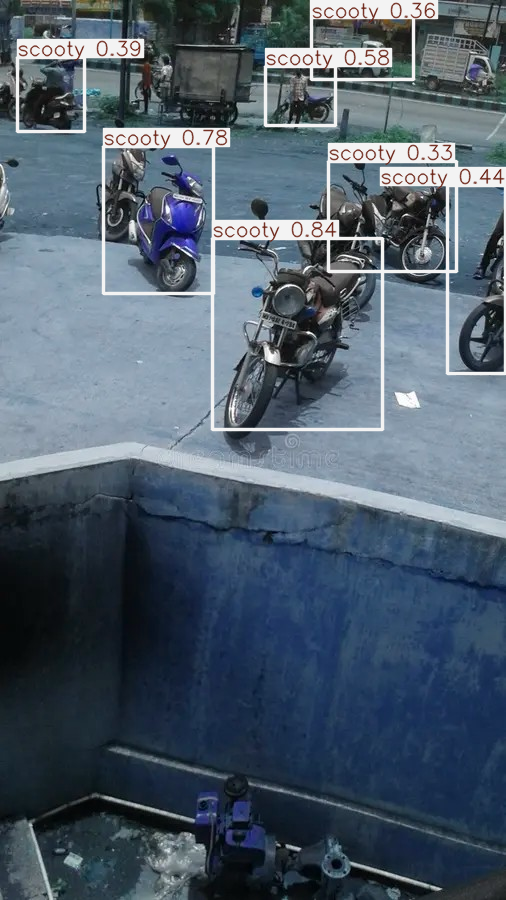


========== IMAGE 2 ==========


array([[[ 99,  85,  66],
        [100,  86,  67],
        [102,  88,  69],
        ...,
        [115, 105,   0],
        [131, 125,  26],
        [151, 145,  50]],

       [[104,  89,  70],
        [103,  88,  69],
        [101,  86,  67],
        ...,
        [136, 125,  14],
        [143, 134,  30],
        [151, 143,  42]],

       [[ 98,  81,  60],
        [ 99,  82,  61],
        [100,  83,  62],
        ...,
        [161, 145,  25],
        [160, 147,  31],
        [157, 146,  32]],

       ...,

       [[ 77, 111, 140],
        [137, 171, 200],
        [103, 135, 164],
        ...,
        [ 37,  34,  30],
        [ 57,  54,  50],
        [ 78,  75,  71]],

       [[172, 206, 235],
        [160, 194, 223],
        [134, 166, 195],
        ...,
        [ 15,  12,   8],
        [ 33,  30,  26],
        [ 48,  45,  41]],

       [[155, 189, 218],
        [156, 190, 219],
        [165, 197, 226],
        ...,
        [ 12,   9,   5],
        [ 18,  15,  11],
        [ 18,  15,  11]]], dtype=uint8)
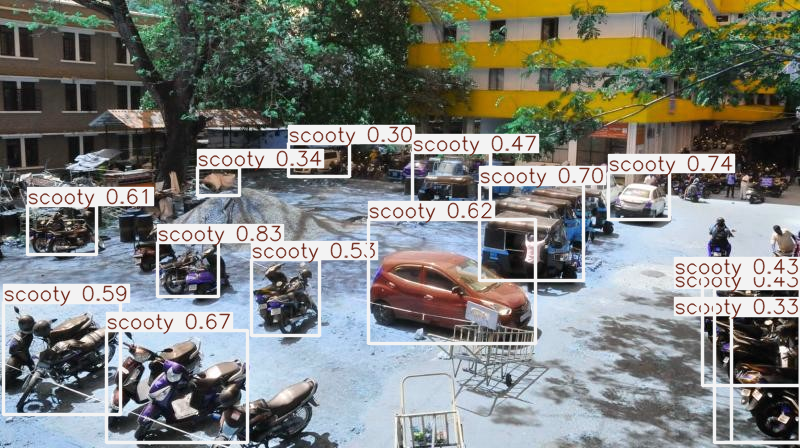


========== IMAGE 3 ==========


array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [252, 252, 252],
        [229, 229, 229]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [254, 254, 254],
        [233, 233, 233]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [254, 254, 254],
        [233, 233, 233]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
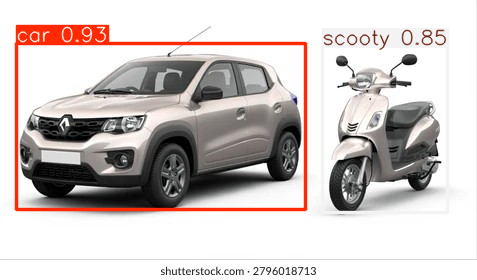

In [47]:
from ultralytics import YOLO
from IPython.display import Image, display
import glob
import os

# Load trained model
model = YOLO("/content/runs/detect/train/weights/best.pt")

# Your 3 images
test_images = [
    "/content/pic.jpg",
    "/content/pic 2.jpg",
    "/content/pic3.jpg"
]

# Predict on all 3
results = model.predict(
    source=test_images,
    conf=0.25,
    save=True
)

# Display all 3 results
print("Number of images processed:", len(results))

for i, result in enumerate(results, start=1):
    print(f"\n========== IMAGE {i} ==========")
    display(result.plot())